# Week 2 — Day 4: Univariate Exploratory Data Analysis

This notebook introduces the first stage of Exploratory Data Analysis
using the Palmer Penguins dataset.

The analysis focuses on examining one variable at a time in order to:

- understand numeric distributions;
- inspect categorical frequencies;
- identify potential outliers;
- notice missing values and possible data-quality problems;
- document findings before making cleaning or modelling decisions.

The main tools used in this notebook are Pandas, Matplotlib, and
Seaborn.

## 1. What Exploratory Data Analysis Means

Exploratory Data Analysis, or EDA, is the process of examining a
dataset before modelling it.

The purpose is not only to create charts. It is to understand the
dataset's structure, distributions, missing values, unusual
observations, and possible data-quality problems.

During this first part of EDA, each variable will be examined
separately. This is known as **univariate analysis**.

The findings from EDA will guide later decisions about data cleaning,
preprocessing, feature selection, and model evaluation.

## 2. Importing the Required Libraries

The following libraries will be used:

- **Pandas** to load, inspect, and organise the dataset.
- **Matplotlib** to control figure size, labels, and chart display.
- **Seaborn** to create statistical visualisations directly from the
  DataFrame.
- **Pathlib** to define the dataset path clearly and independently of
  the operating system.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

## 3. Loading the Dataset

The Palmer Penguins dataset contains physical measurements and
categorical information about penguins observed on several islands.

Before creating visualisations or making cleaning decisions, the
dataset will be loaded and inspected to confirm that:

- the file is available at the expected location;
- the rows and columns were loaded correctly;
- the column names and data types are understood;
- numeric and categorical variables can be identified;
- possible missing values can be investigated later.

In [2]:
data_path = Path("../data/penguins.csv")
df = pd.read_csv(data_path)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 4. Inspecting the Dataset Structure

A first inspection helps confirm the size and structure of the dataset
before analysing its distributions.

The inspection will include:

- the number of rows and columns;
- the column names;
- the data type of each column;
- the number of non-missing values in each column.

Understanding data types is especially important because numeric and
categorical variables require different analysis methods and different
preprocessing steps before machine learning.

In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("Column names:")
print(df.columns.tolist())

Number of rows: 344
Number of columns: 8
Column names:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


### Column Types and Non-Missing Values

The `info()` method provides a compact summary of the DataFrame. It
shows the column names, the number of non-missing values, and the data
type assigned to each column.

This check is important because an incorrect data type can prevent
valid calculations or cause a machine-learning pipeline to treat a
variable incorrectly.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


### Separating Numeric and Categorical Variables

Numeric and categorical variables will be identified separately because
they require different forms of univariate analysis.

Numeric variables can be studied using histograms, KDE curves, and box
plots. Categorical variables are better examined using frequency tables
and count plots.

In [5]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Numeric columns:")
print(numeric_columns)
print()
print("Categorical columns:")
print(categorical_columns)

Numeric columns:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']

Categorical columns:
['species', 'island', 'sex']


### Analytical Roles of the Variables

Pandas identifies the `year` column as numeric because its values are
stored as integers. However, its analytical role is different from
physical measurements such as body mass or flipper length.

In this notebook, the main measurement variables will be analysed using
histograms and box plots. The `year` column will be treated as a set of
discrete observation periods and examined using a count plot.

This distinction shows that a variable's stored data type does not always
determine the most appropriate way to analyse it.

In [6]:
measurement_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
category_columns = [
    "species",
    "island",
    "sex",
    "year",
]
print("Measurement columns:")
print(measurement_columns)
print("\nColumns analysed as categories:")
print(category_columns)

Measurement columns:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

Columns analysed as categories:
['species', 'island', 'sex', 'year']


## 5. Checking Data Quality

Before analysing distributions, the dataset should be checked for
missing values and duplicate rows.

Missing values reduce the amount of usable information and may prevent
some machine-learning algorithms from training correctly. Duplicate rows
may give repeated observations more influence than they should have.

At this stage, the purpose is to identify these issues rather than
modify the dataset immediately. Any cleaning decision should be based on
the meaning, amount, and location of the affected data.

### 5.1 Missing Values

The number and percentage of missing values will be calculated for every
column.

The count shows how many observations are missing, while the percentage
helps judge whether the problem affects a small or large part of the
dataset.

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
})
missing_summary

,missing_count,missing_percentage
species,0,0.00
island,0,0.00
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
sex,11,3.20
year,0,0.00


### 5.2 Rows Containing Missing Values

Rows containing at least one missing value will be displayed to examine
whether the missing data appears in isolated cells or in repeated
patterns across several columns.

This inspection may help determine whether a row is still useful for
some analyses even when one of its values is unavailable.

In [8]:
rows_with_missing = df[df.isna().any(axis=1)]
print(f"Rows containing at least one missing value: {len(rows_with_missing)}")
rows_with_missing

Rows containing at least one missing value: 11


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


### 5.3 Duplicate Rows

An exact duplicate is a row whose values match another row across all
columns.

Duplicate observations can distort counts, summary statistics, and
machine-learning models by giving repeated records additional weight.
However, repeated category values are not duplicates unless the complete
rows are identical.

In [9]:
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

Number of exact duplicate rows: 0


### Data-Quality Findings

The dataset contains 11 rows with at least one missing value. The `sex`
column has the largest amount of missing data, with 11 missing values
representing 3.20% of the dataset.

Each physical measurement column contains only 2 missing values,
representing 0.58% of the dataset. Inspection of the affected rows shows
that the same two observations are missing all four physical measurements,
while the remaining incomplete rows are missing only the `sex` value.

No exact duplicate rows were found. Therefore, duplicate removal is not
required at this stage.

These missing values will not be modified yet. Their treatment will depend
on the requirements of each analysis and, later, the preprocessing strategy
used for machine learning.

### Data-Quality Decision at This Stage

The original DataFrame will remain unchanged during the initial
inspection.

Missing values will be handled separately according to the variable and
the purpose of each analysis. No rows will be removed or filled without
a documented reason.

This approach preserves the original data and avoids changing
distributions before they are properly examined.

## 6. Analysing Numeric Distributions

A distribution describes how the observed values of a variable are spread
across its possible range. Examining distributions helps reveal the centre,
spread, skewness, gaps, multiple peaks, and potentially unusual values in
each measurement.

Histograms will be used to show how many observations fall within different
value intervals. A KDE curve will also be included as a smoothed estimate of
the overall distribution shape.

The four physical measurement columns will be analysed separately. Missing
values are not removed from the original DataFrame; Seaborn excludes only
the unavailable values from the relevant plot.

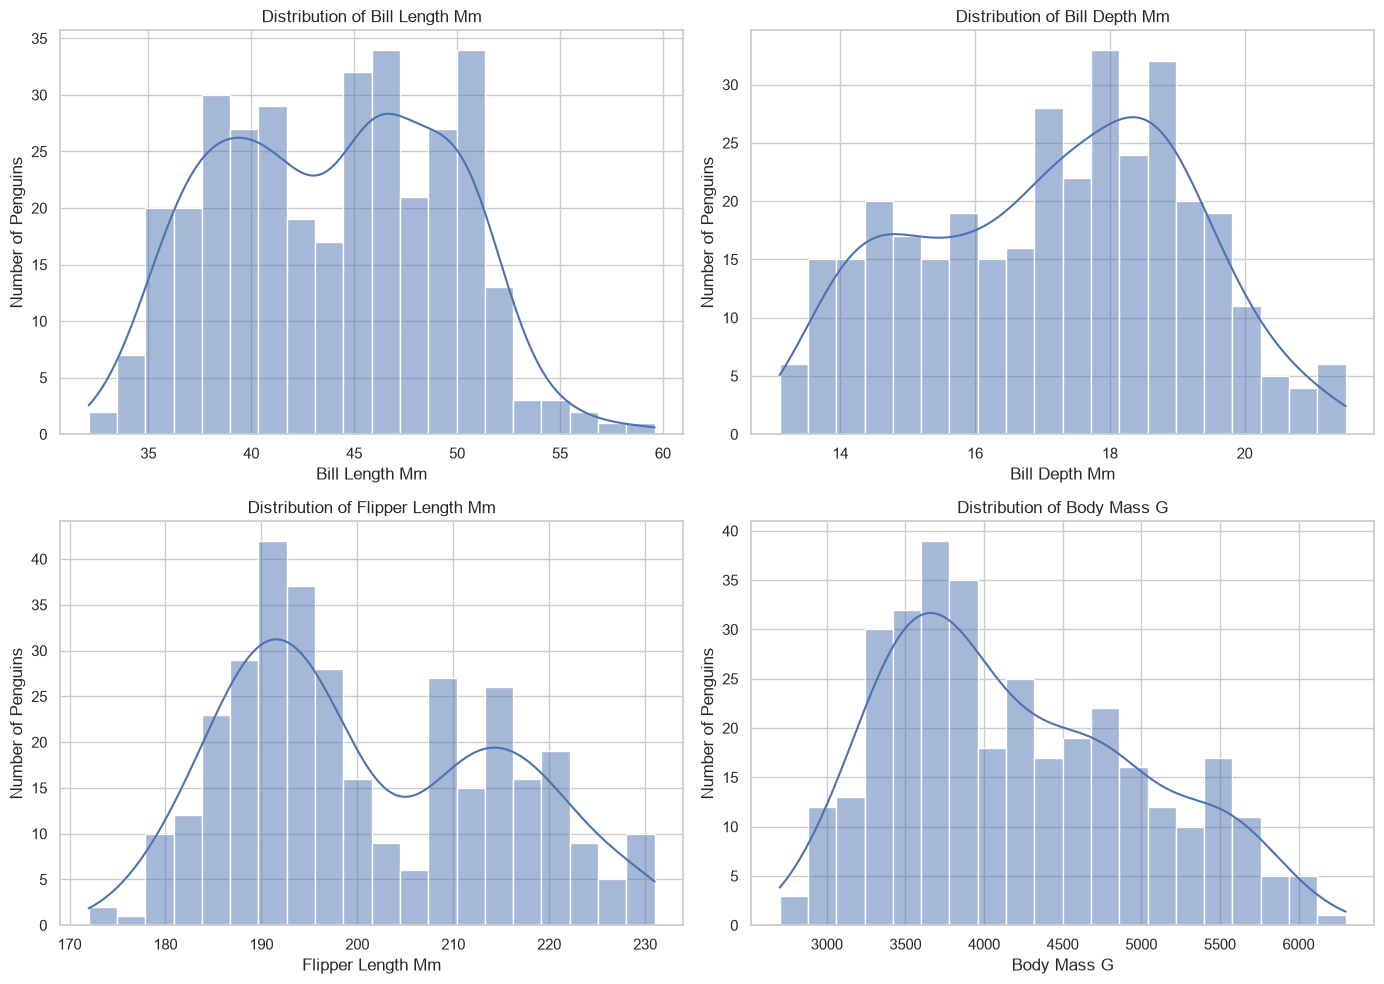

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for column, ax in zip(measurement_columns, axes.flatten()):
    sns.histplot(
        data=df,
        x=column,
        bins=20,
        kde=True,
        ax=ax,
    )

    readable_title = column.replace("_", " ").title()
    ax.set_title(f"Distribution of {readable_title}")
    ax.set_xlabel(readable_title)
    ax.set_ylabel("Number of Penguins")

plt.tight_layout()
plt.show()

### Interpretation of the Numeric Distributions

The four physical measurements do not appear to follow simple, single-peaked
normal distributions.

`bill_length_mm` shows two noticeable areas of concentration, with shorter
bills clustered around approximately 38–41 mm and longer bills around
approximately 45–51 mm. `bill_depth_mm` also has a broad distribution with
more than one area of concentration.

The clearest separation appears in `flipper_length_mm`, where one group is
concentrated around approximately 188–197 mm and another around approximately
208–220 mm. `body_mass_g` similarly contains a large concentration of lighter
penguins and another region containing heavier observations.

These multiple peaks may indicate that the dataset contains naturally
different subgroups. However, the cause cannot be confirmed using univariate
plots alone and will require comparison with categorical variables later.

No observations will be removed based only on these histograms. A value that
looks unusual in the overall distribution may still be valid for a particular
group of penguins.

## 7. Inspecting Potential Outliers with Box Plots

A box plot summarizes a numeric variable using its median, quartiles, and
interquartile range. Values plotted beyond the whiskers are commonly flagged
as potential outliers.

These points are not automatically errors. A box plot only identifies values
that are unusual according to the IQR rule. Each flagged observation must be
investigated before deciding whether it should be kept, corrected, capped, or
removed.

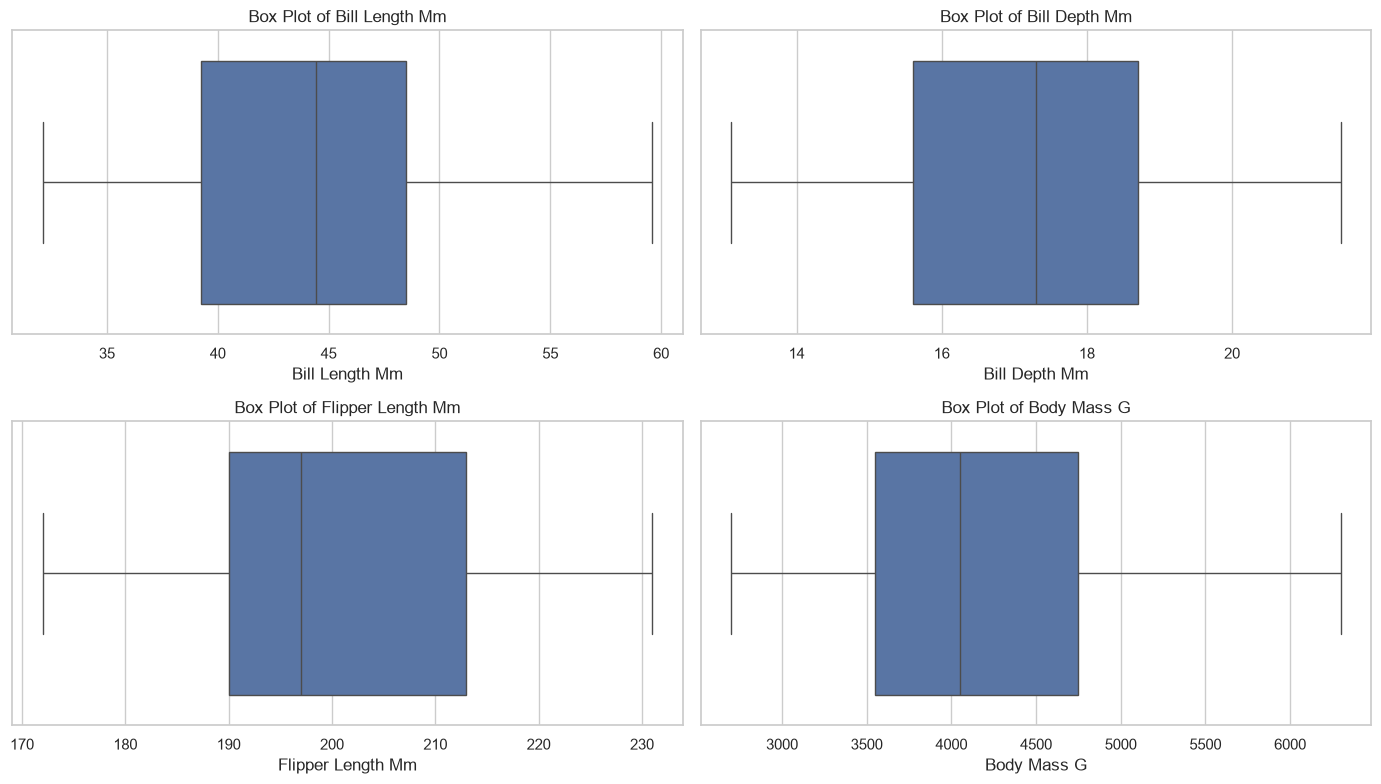

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for column, ax in zip(measurement_columns, axes.flatten()):
    sns.boxplot(
    data=df,
    x=column,
    ax=ax,
    )
    readable_title = column.replace("_", " ").title()
    ax.set_title(f"Box Plot of {readable_title}")
    ax.set_xlabel(readable_title)
    
plt.tight_layout()
plt.show()

### Interpretation of the Box Plots

The box plots do not show any individual points beyond the whiskers for the
four physical measurements. Therefore, no observations are visually flagged
as potential outliers by the default box-plot rule.

The variables have different amounts of spread, but a wide range alone does
not mean that a variable contains outliers. The earlier histograms also showed
multiple areas of concentration in some measurements, which a box plot cannot
display clearly.

The visual result will be verified numerically using the IQR method before any
decision is made. No values will be removed or modified based only on the
plots.

## 8. Verifying Potential Outliers with the IQR Method

The box plots provide a visual indication of potential outliers, but the IQR
method will now be applied numerically to each physical measurement.

For each variable, the first quartile (Q1), third quartile (Q3), and
interquartile range are calculated. Values below `Q1 - 1.5 × IQR` or above
`Q3 + 1.5 × IQR` are flagged for investigation.

Being flagged does not prove that a value is incorrect. The method only
identifies observations that are unusually far from the middle 50% of the
data.

In [12]:
outlier_summary = []

for column in measurement_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_summary.append(
        {
            "column": column,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "lower_bound": round(lower_bound, 2),
            "upper_bound": round(upper_bound, 2),
            "outlier_count": outlier_count,
        }
    )
    
outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,bill_length_mm,39.22,48.5,9.27,25.31,62.41,0
1,bill_depth_mm,15.60,18.7,3.10,10.95,23.35,0
2,flipper_length_mm,190.00,213.0,23.00,155.50,247.50,0
3,body_mass_g,3550.00,4750.0,1200.00,1750.00,6550.00,0


### IQR Outlier-Detection Results

The numerical IQR calculation confirms the visual box-plot results. None of
the four physical measurement columns contains values below its calculated
lower bound or above its upper bound.

The IQR method therefore flags zero potential outliers in `bill_length_mm`,
`bill_depth_mm`, `flipper_length_mm`, and `body_mass_g`.

No observations will be removed, capped, or modified for outlier treatment at
this stage. The variables still show different distribution shapes and
multiple areas of concentration, but these characteristics should not be
confused with outliers.

## 9. Analysing Categorical Distributions

Categorical distributions show how observations are divided among the
different groups in a variable. Count plots will be used to compare the
frequency of each category in `species`, `island`, `sex`, and `year`.

This analysis helps identify dominant or underrepresented categories that may
influence later statistical analysis and machine-learning evaluation.

Missing values in `sex` will be displayed as a separate category for this
visualisation. This makes the missing observations visible without modifying
the original DataFrame.

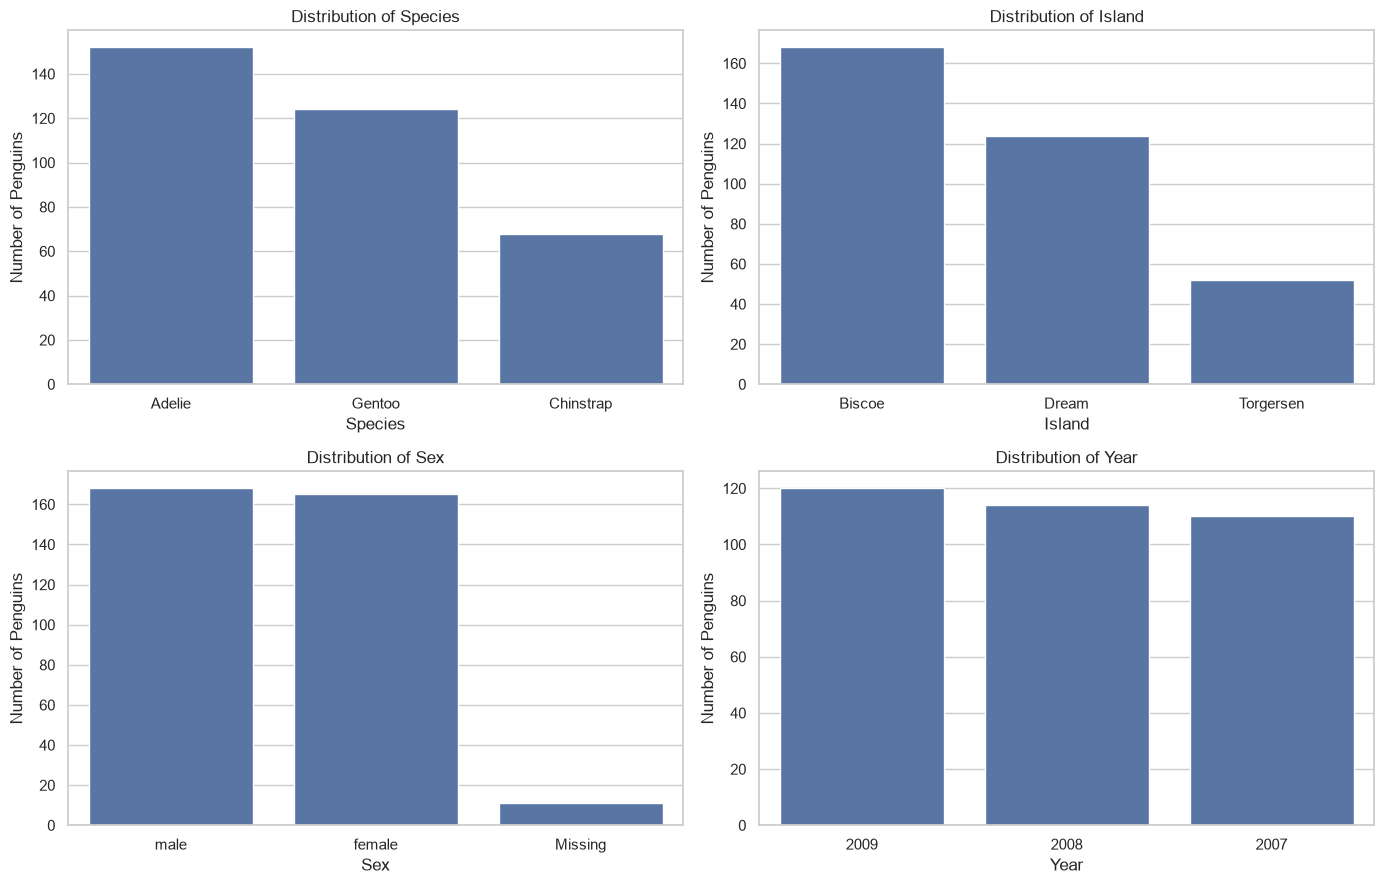

In [13]:
categorical_columns = ["species", "island", "sex", "year"]
categorical_plot_data = df[categorical_columns].copy()
categorical_plot_data["sex"] = categorical_plot_data["sex"].fillna("Missing")
categorical_plot_data["year"] = categorical_plot_data["year"].astype(str)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for column, ax in zip(categorical_columns, axes.flatten()):
    category_order = categorical_plot_data[column].value_counts().index
    sns.countplot(
        data=categorical_plot_data,
        x=column,
        order=category_order,
        ax=ax,
    )
    readable_title = column.replace("_", " ").title()
    ax.set_title(f"Distribution of {readable_title}")
    ax.set_xlabel(readable_title)
    ax.set_ylabel("Number of Penguins")

plt.tight_layout()
plt.show()

### Interpretation of the Categorical Distributions

The categorical variables have different levels of balance.

`species` is moderately imbalanced. Adelie is the most frequently observed
species, while Chinstrap has the fewest observations. If species is later used
as a prediction target, this difference should be considered when splitting
the data and evaluating model performance.

The island distribution is also uneven. Biscoe contains the largest number of
observations, while Torgersen contains the fewest. This does not automatically
indicate a data-quality problem, because the difference may reflect the
original sampling process.

The recorded male and female counts are very similar, so `sex` is approximately
balanced among the known values. However, 11 observations have a missing sex
value, and these will require a documented preprocessing decision if the
variable is used in a future model.

The observations are distributed fairly evenly across 2007, 2008, and 2009,
with only small differences between the three years.

### Categorical Frequency Summary

The count plots provide a visual comparison, while the following table reports
the exact count and percentage of each category.

Missing values in `sex` are included as a separate category so that the
percentages represent the full dataset. The original DataFrame remains
unchanged.

In [14]:
categorical_summary = []

for column in categorical_columns:
    counts = categorical_plot_data[column].value_counts(dropna=False)
    percentages = categorical_plot_data[column].value_counts(
        normalize=True,
        dropna=False,
    ) * 100
    for category in counts.index:
        categorical_summary.append(
            {
                "column": column,
                "category": category,
                "count": counts[category],
                "percentage": round(percentages[category], 2),
            }
        )
        
categorical_summary_df = pd.DataFrame(categorical_summary)
categorical_summary_df

,column,category,count,percentage
0,species,Adelie,152,44.19
1,species,Gentoo,124,36.05
2,species,Chinstrap,68,19.77
3,island,Biscoe,168,48.84
4,island,Dream,124,36.05
5,island,Torgersen,52,15.12
6,sex,male,168,48.84
7,sex,female,165,47.97
8,sex,Missing,11,3.20
9,year,2009,120,34.88


### Categorical Frequency Results

The exact frequency calculations confirm the patterns observed in the count
plots.

Adelie is the most represented species with 152 observations (44.19%),
followed by Gentoo with 124 observations (36.05%). Chinstrap has the fewest
observations with 68 (19.77%), indicating uneven class representation in the
species variable.

The island distribution is more uneven. Biscoe contains 168 observations
(48.84%), Dream contains 124 (36.05%), and Torgersen contains only 52
(15.12%). This difference may reflect the original sampling process and is not
treated as a data-quality error.

The recorded sex values are nearly balanced, with 168 males (48.84%) and
165 females (47.97%). A further 11 observations (3.20%) have a missing sex
value. These missing values remain unchanged in the original DataFrame.

The yearly observations are distributed fairly evenly across 2007, 2008,
and 2009, with percentages ranging from 31.98% to 34.88%.

No categories will be removed or resampled during this exploratory stage.
Any future treatment of imbalance will depend on the modelling objective and
evaluation results.

## 10. Day 4 Summary and Decisions

This univariate EDA examined each variable independently before any modelling
or major cleaning decisions were made.

The dataset contains 11 rows with at least one missing value. The `sex`
column contains 11 missing values, while two observations are missing all four
physical measurements. No exact duplicate rows were found.

The numeric histograms show that several physical measurements have multiple
areas of concentration rather than simple single-peaked distributions. These
patterns may reflect natural subgroups in the dataset, but their cause cannot
be confirmed through univariate analysis alone.

The box plots and numerical IQR calculations identified zero potential
outliers in the four physical measurement columns. Therefore, no values were
removed, capped, or modified for outlier treatment.

The categorical analysis found moderate imbalance in `species` and a more
uneven distribution across `island`. Recorded male and female observations are
nearly balanced, while the three years are represented fairly evenly.

The original DataFrame remains unchanged. Missing-value treatment and any
future response to class imbalance will be decided later according to the
specific analysis or machine-learning task.